### Imports

In [1]:
import json
from pathlib import Path

import optuna
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoTokenizer

from src.config import CONFIG
from src.models.nli_dataset import NLIDataset
from src.models.transformer_classifier import TransformerClassifier
from src.utils import run_sweep, plot_training_history


/Users/jackrong/University/34812-cwk-S-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
TRAIN_DATA_PATH = Path(f'../data/train.csv')
VAL_DATA_PATH = Path(f'../data/dev.csv')

HYPERPARAMETERS_PATH = Path(f'../hyperparameters/transformer.json')
MODEL_PATH = Path(f'../models/transformer.pt')

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Set a constant seed for reproducability

In [4]:
generator = torch.manual_seed(CONFIG.seed)

### Set up Datasets and DataLoaders

In [5]:
train_pd = pd.read_csv(TRAIN_DATA_PATH)
val_pd = pd.read_csv(VAL_DATA_PATH)

tokeniser = AutoTokenizer.from_pretrained(CONFIG.transformer.model)
train_dataset = NLIDataset(train_pd, tokeniser, CONFIG.transformer.max_length)
val_dataset = NLIDataset(val_pd, tokeniser, CONFIG.transformer.max_length)

train_dataloader = DataLoader(train_dataset, generator=generator, batch_size=CONFIG.batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, generator=generator, batch_size=CONFIG.batch_size, shuffle=False)

### Training Functions

In [6]:
def train_one_epoch(device, model, criterion, optimiser, train_dataloader) -> tuple[float, float]:
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(train_dataloader, desc='Training', unit='batches'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimiser.zero_grad(set_to_none=True)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimiser.step()

        total_loss += loss.item()
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def validate(device, model, criterion, val_dataloader) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    with torch.inference_mode():
        for batch in tqdm(val_dataloader, desc='Validating', unit='batches'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Hyperparameter Tuning

In [7]:
def objective(trial) -> float:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)

    model = TransformerClassifier(num_labels=2, dropout=dropout).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(CONFIG.hyperparameter_tuning.epochs):
        train_one_epoch(device, model, criterion, optimiser, train_dataloader)
        val_loss, val_acc = validate(device, model, criterion, val_dataloader)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

if CONFIG.hyperparameter_tuning.should_run:
    run_sweep(objective, HYPERPARAMETERS_PATH)

### Training Loop

Hyperparameters used: {'lr': 0.0026610255140163165, 'dropout': 0.3351541844897266}



Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8649.83it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training transformer model...
[Epoch 1/20]


Validating: 100%|██████████| 106/106 [00:14<00:00,  7.50batches/s]


Train Loss: 0.01 | Train Accuracy: 57.39% | Val Loss: 0.01 | Val Accuracy: 61.51%

[Epoch 2/20]


...

Train Loss: 0.01 | Train Accuracy: 59.74% | Val Loss: 0.01 | Val Accuracy: 62.05%

[Epoch 19/20]


Validating: 100%|██████████| 106/106 [16:08<00:00,  9.14s/batches]  


Train Loss: 0.01 | Train Accuracy: 59.66% | Val Loss: 0.01 | Val Accuracy: 60.61%

[Epoch 20/20]


Validating: 100%|██████████| 106/106 [49:43<00:00, 28.15s/batches]  


Train Loss: 0.01 | Train Accuracy: 59.74% | Val Loss: 0.01 | Val Accuracy: 62.14%

Best model had an accuracy of 62.40%.
Running final test...


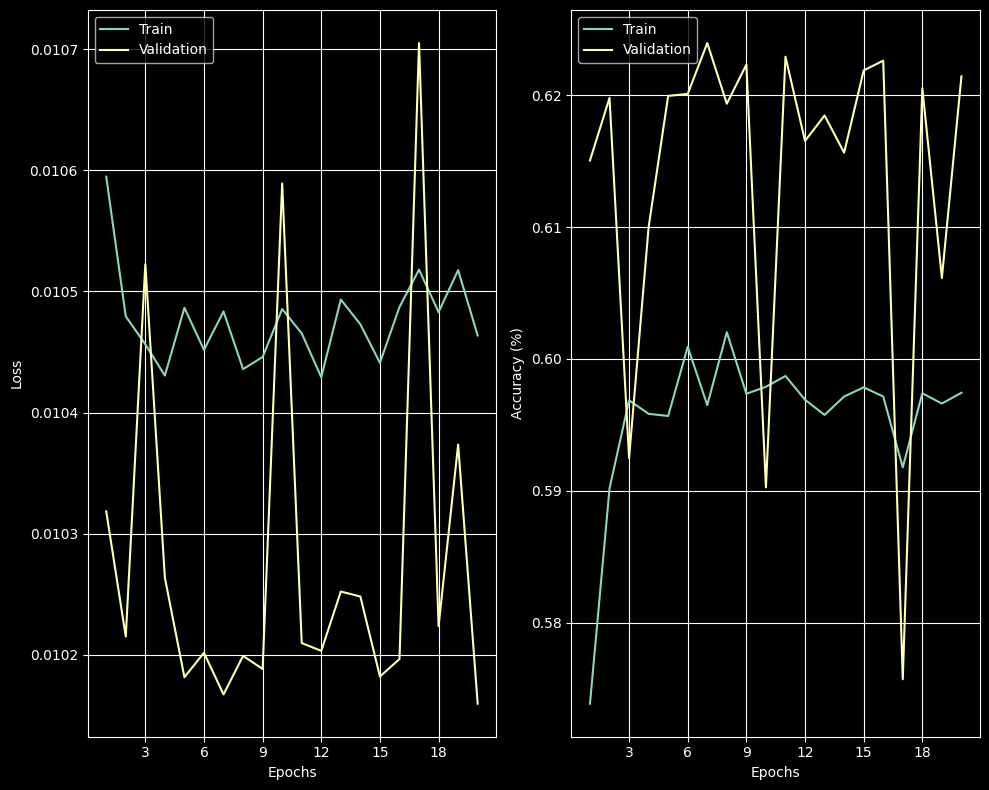

In [8]:
if __name__ == '__main__':
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    model = TransformerClassifier(num_labels=2, dropout=hyperparameters['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training transformer model...')
    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(CONFIG.epochs):
        print(f'[Epoch {epoch + 1}/{CONFIG.epochs}]')

        train_loss, train_acc = train_one_epoch(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc * 100:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc * 100:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_acc * 100:.2f}%.')
    print(f'Running final test...')
    model.load_state_dict(torch.load(MODEL_PATH))

    # TODO: Benchmark

    plot_training_history(train_losses, train_accs, val_losses, val_accs)